# Load and Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving player-groups.csv to player-groups.csv


In [3]:
df = pd.read_csv('player-groups.csv')

In [4]:
df = pd.read_csv('player-groups.csv', sep=";", quotechar='"')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   number   1 non-null      int64  
 1   season   1 non-null      object 
 2   team     1 non-null      object 
 3   apps     1 non-null      int64  
 4   min      1 non-null      int64  
 5   goals    1 non-null      int64  
 6   assists  1 non-null      int64  
 7   sp90m    1 non-null      float64
 8   kp90     1 non-null      float64
 9   xG       1 non-null      float64
 10  xA       1 non-null      float64
 11  xG90     1 non-null      float64
 12  xA90     1 non-null      float64
dtypes: float64(6), int64(5), object(2)
memory usage: 236.0+ bytes


In [6]:
df.head()

,number,season,team,apps,min,goals,assists,sp90m,kp90,xG,xA,xG90,xA90
0,1,2025/2026,Arsenal,32,2079,12,0,2.08,0.74,11.43,2.21,0.49,0.1


In [7]:
from google.colab import files
uploaded = files.upload()

Saving player-groups (1).csv to player-groups (1).csv


In [8]:
df1 = pd.read_csv('player-groups (1).csv')

In [9]:
import pandas as pd

df1 = pd.read_csv('player-groups (1).csv', sep=";", quotechar='"')

In [10]:
df1.info()
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   number    2 non-null      int64  
 1   position  2 non-null      object 
 2   apps      2 non-null      int64  
 3   min       2 non-null      int64  
 4   goals     2 non-null      int64  
 5   assists   2 non-null      int64  
 6   sp90m     2 non-null      float64
 7   kp90      2 non-null      float64
 8   xG        2 non-null      float64
 9   xA        2 non-null      float64
 10  xG90      2 non-null      float64
 11  xA90      2 non-null      float64
dtypes: float64(6), int64(5), object(1)
memory usage: 324.0+ bytes


,number,position,apps,min,goals,assists,sp90m,kp90,xG,xA,xG90,xA90
0,1,FW,24,1877,9,0,2.06,0.72,9.94,2.02,0.48,0.10
1,2,Sub,8,202,3,0,2.23,0.89,1.50,0.19,0.67,0.08


In [11]:
image_url = "https://upload.wikimedia.org/wikipedia/commons/7/7c/Viktor_Gyokeres_2023.jpg"

In [12]:
print(image_url)

https://upload.wikimedia.org/wikipedia/commons/7/7c/Viktor_Gyokeres_2023.jpg


In [13]:
import pandas as pd

data = {
    "number": [1, 2],
    "position": ["FW", "Sub"],
    "apps": [24, 8],
    "min": [1877, 202],
    "goals": [9, 3],
    "assists": [0, 0],
    "sp90m": [2.06, 2.23],
    "kp90": [0.72, 0.89],
    "xG": [9.94, 1.50],
    "xA": [2.02, 0.19],
    "xG90": [0.48, 0.67],
    "xA90": [0.10, 0.08]
}

df = pd.DataFrame(data)
df

,number,position,apps,min,goals,assists,sp90m,kp90,xG,xA,xG90,xA90
0,1,FW,24,1877,9,0,2.06,0.72,9.94,2.02,0.48,0.10
1,2,Sub,8,202,3,0,2.23,0.89,1.50,0.19,0.67,0.08


In [14]:
# Goal efficiency
df["goal_vs_xG"] = df["goals"] - df["xG"]

# Contribution per 90
df["contribution_90"] = df["xG90"] + df["xA90"]

# Finishing efficiency ratio
df["finishing_ratio"] = df["goals"] / df["xG"]

In [15]:
role_summary = df.groupby("position").agg({
    "apps": "sum",
    "min": "sum",
    "goals": "sum",
    "xG": "sum",
    "xA": "sum",
    "xG90": "mean",
    "xA90": "mean"
}).reset_index()

role_summary

,position,apps,min,goals,xG,xA,xG90,xA90
0,FW,24,1877,9,9.94,2.02,0.48,0.10
1,Sub,8,202,3,1.50,0.19,0.67,0.08


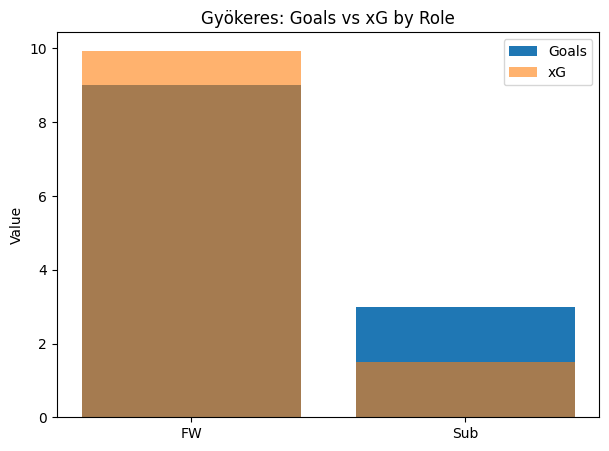

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(df["position"], df["goals"], label="Goals")
plt.bar(df["position"], df["xG"], alpha=0.6, label="xG")

plt.title("Gyökeres: Goals vs xG by Role")
plt.ylabel("Value")
plt.legend()
plt.show()

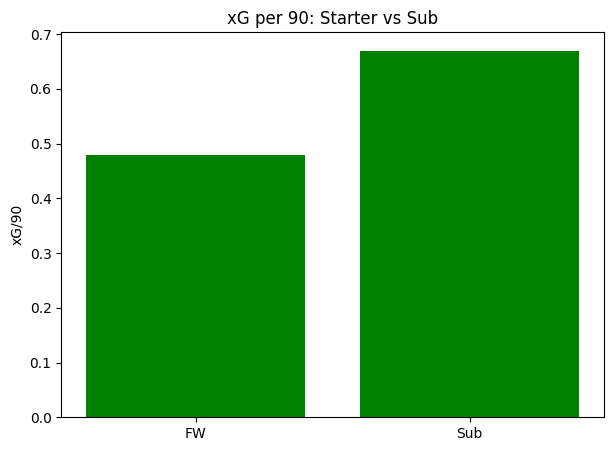

In [17]:
plt.figure(figsize=(7,5))

plt.bar(df["position"], df["xG90"], color="green")

plt.title("xG per 90: Starter vs Sub")
plt.ylabel("xG/90")
plt.show()

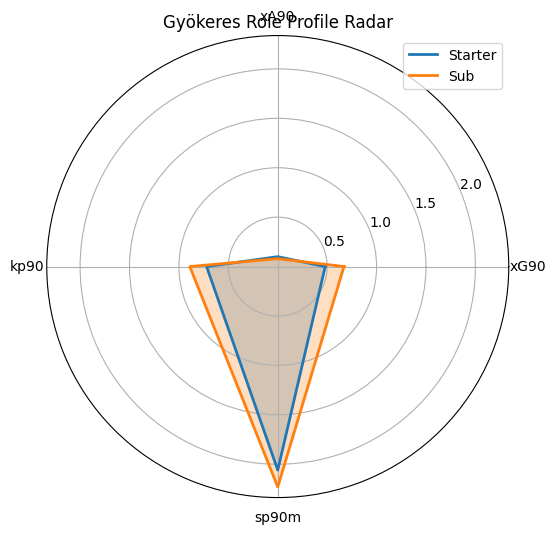

In [18]:
from math import pi

categories = ["xG90", "xA90", "kp90", "sp90m"]

starter = df[df["position"]=="FW"][categories].values.flatten().tolist()
sub = df[df["position"]=="Sub"][categories].values.flatten().tolist()

starter += starter[:1]
sub += sub[:1]

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

fig = plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

plt.xticks(angles[:-1], categories)

ax.plot(angles, starter, linewidth=2, label="Starter")
ax.fill(angles, starter, alpha=0.25)

ax.plot(angles, sub, linewidth=2, label="Sub")
ax.fill(angles, sub, alpha=0.25)

plt.title("Gyökeres Role Profile Radar")
plt.legend()
plt.show()

In [19]:
from google.colab import files
uploaded = files.upload()

Saving player-groups (2).csv to player-groups (2).csv


In [20]:
df2 = pd.read_csv('player-groups (2).csv')

In [21]:
df2 = pd.read_csv('player-groups (2).csv', sep=";", quotechar='"')

In [22]:
df2.info()
df2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   number     4 non-null      int64  
 1   situation  4 non-null      object 
 2   shots      4 non-null      int64  
 3   goals      4 non-null      int64  
 4   kp         4 non-null      int64  
 5   assists    4 non-null      int64  
 6   xG         4 non-null      float64
 7   xA         4 non-null      float64
 8   xG90       4 non-null      float64
 9   xA90       4 non-null      float64
 10  xGperSh    4 non-null      float64
 11  xAperKP    4 non-null      float64
dtypes: float64(6), int64(5), object(1)
memory usage: 516.0+ bytes


,number,situation,shots,goals,kp,assists,xG,xA,xG90,xA90,xGperSh,xAperKP
0,1,Open play,41,8,15,0,7.94,1.68,0.34,0.07,0.19,0.11
1,2,Penalty,3,3,0,0,2.28,0.00,0.10,0.00,0.76,0.00
2,3,From corner,2,1,1,0,0.73,0.47,0.03,0.02,0.37,0.47
3,4,Set piece,2,0,1,0,0.48,0.06,0.02,0.00,0.24,0.06


In [23]:
from google.colab import files
uploaded = files.upload()

Saving player-groups (3).csv to player-groups (3).csv


In [24]:
df3 = pd.read_csv('player-groups (3).csv')

In [25]:
df3 = pd.read_csv('player-groups (3).csv', sep=";", quotechar='"')

In [26]:
df3.info()
df3.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   number     3 non-null      int64  
 1   shotZones  3 non-null      object 
 2   shots      3 non-null      int64  
 3   goals      3 non-null      int64  
 4   kp         3 non-null      int64  
 5   assists    3 non-null      int64  
 6   xG         3 non-null      float64
 7   xA         3 non-null      float64
 8   xGperSh    3 non-null      float64
 9   xAperKP    3 non-null      float64
dtypes: float64(4), int64(5), object(1)
memory usage: 372.0+ bytes


,number,shotZones,shots,goals,kp,assists,xG,xA,xGperSh,xAperKP
0,1,Out of box,4,1,3,0,0.25,0.08,0.06,0.03
1,2,Penalty area,34,7,12,0,6.59,1.59,0.19,0.13
2,3,Six-yard box,10,4,2,0,4.60,0.53,0.46,0.27


In [27]:
from google.colab import files
uploaded = files.upload()

Saving player-groups (4).csv to player-groups (4).csv


In [28]:
df4 = pd.read_csv('player-groups (4).csv')

In [29]:
df4 = pd.read_csv('player-groups (4).csv', sep=";", quotechar='"')

In [30]:
df4.info()
df4.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   number     4 non-null      int64  
 1   shotTypes  4 non-null      object 
 2   shots      4 non-null      int64  
 3   goals      4 non-null      int64  
 4   kp         4 non-null      int64  
 5   assists    4 non-null      int64  
 6   xG         4 non-null      float64
 7   xA         4 non-null      float64
 8   xGperSh    4 non-null      float64
 9   xAperKP    4 non-null      float64
dtypes: float64(4), int64(5), object(1)
memory usage: 452.0+ bytes


,number,shotTypes,shots,goals,kp,assists,xG,xA,xGperSh,xAperKP
0,1,Right foot,31,10,7,0,8.82,0.89,0.28,0.13
1,2,Head,12,1,4,0,1.89,0.59,0.16,0.15
2,3,Left foot,4,1,6,0,0.68,0.72,0.17,0.12
3,4,Other body part,1,0,0,0,0.05,0.00,0.05,0.00
